In [73]:
# CELL 1 — КОНФИГ / ПУТИ 
import os

SEED = 42
TEXT_COL = "supplier_room_name"
TARGET_COL = "target"

# --- LightGBM артефакты 
LGB_ARTIFACTS_DIR = "/kaggle/input/datasets/liaawies/nnnewartlgb/light_GBM art"  
LGB_TRAIN_PATH = "/kaggle/input/datasets/liaawies/public-dataset4/public_dataset.csv"  
LGB_TEST_SIZE = 0.15   
LGB_N_FOLDS = 8        

# --- BERT артефакты ---
BERT_ARTIFACTS_DIR = "/kaggle/input/datasets/liaawies/beert-art"  
BERT_TRAIN_PATH = "/kaggle/input/datasets/liaawies/public-dataset4/public_dataset.csv"  
BERT_MODEL_NAME = "distilbert-base-multilingual-cased"
BERT_MAX_LEN = 64
BERT_VALID_SIZE = 0.15  

# --- Финальный сабмит ---
FINAL_TEST_PATH = "/kaggle/input/datasets/liaawies/submission-sample/new_submission_sample (3) (1).csv"  
LGB_FINAL_SUBMISSION_CSV = os.path.join(LGB_ARTIFACTS_DIR, "/kaggle/input/datasets/liaawies/lgb-newsub/submission_lgb_FINAL.csv")  
BERT_FINAL_PROBS_NPY = os.path.join(BERT_ARTIFACTS_DIR, "/kaggle/input/datasets/liaawies/beert-art/test_bert_probs.npy")

WORKING_DIR = "/kaggle/working/stacking"
os.makedirs(WORKING_DIR, exist_ok=True)

print("Пути настроены")

Пути настроены


In [74]:
# CELL 2 — те же функции фичей, что в lightgbm-ноутбуке 
import re
import numpy as np
import pandas as pd

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return None
    original = text.strip()
    if re.fullmatch(r'[\d\s\W]+', original):
        return None
    text = original.lower()
    text = re.sub(r'[^a-zа-яё0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if len(text.split()) < 2:
        return None
    return text

EURO_MARKERS = {
    "de": r"\b(doppelzimmer|einzelzimmer|zimmer|familienzimmer|suite|mit)\b",
    "fr": r"\b(chambre|singuliere|vue|avec|lit|familiale|superieure)\b",
    "it": r"\b(camera|matrimoniale|singola|doppia|vista|con|letto|superiore)\b",
    "es": r"\b(habitacion|doble|individual|con|vista|cama|superior)\b",
}

def has_foreign_language(text: str) -> int:
    if not isinstance(text, str) or text.strip() == "":
        return 0
    t = text.lower()
    for pattern in EURO_MARKERS.values():
        if re.search(pattern, t):
            return 1
    return 0

def add_features(df_: pd.DataFrame) -> pd.DataFrame:
    df_ = df_.copy()
    text = df_["text_clean"].fillna("")
    orig = df_["supplier_room_name"].fillna("")

    df_["text_length"] = orig.apply(len)
    df_["word_count"] = text.apply(lambda x: len(x.split()))
    df_["unique_ratio"] = text.apply(lambda x: len(set(x.split())) / max(len(x.split()), 1))
    df_["upper_ratio"] = orig.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    df_["has_parentheses"] = orig.apply(lambda x: int("(" in x))
    df_["digit_count"] = orig.apply(lambda x: sum(1 for c in x if c.isdigit()))

    df_["ru_ratio"] = text.apply(lambda x: sum(1 for c in x if 'а' <= c <= 'я' or c == 'ё') / max(len(x), 1))
    df_["en_ratio"] = text.apply(lambda x: sum(1 for c in x if 'a' <= c <= 'z') / max(len(x), 1))
    df_["has_foreign_lang"] = orig.apply(has_foreign_language)

    bed_configs = ["king", "queen", "twin", "double", "single", "bunk",
                   "двуспальн", "односпальн", "1 bed", "2 bed",
                   "1 кровать", "2 кровати", "2 отдельные"]
    df_["has_bed_config"] = text.apply(lambda x: int(any(b in x for b in bed_configs)))

    room_levels = ["standard", "стандарт", "deluxe", "делюкс", "superior", "executive",
                   "premium", "премиум", "classic", "comfort", "комфорт", "люкс", "economy"]
    df_["has_room_level"] = text.apply(lambda x: int(any(r in x for r in room_levels)))

    view_words = ["sea view", "ocean view", "вид на море", "city view", "вид на город",
                  "garden view", "pool view", "mountain view", " view", " вид"]
    df_["has_view"] = text.apply(lambda x: int(any(v in x for v in view_words)))

    balcony_words = ["balcon", "terrace", "террас", "балкон", "лоджия"]
    df_["has_balcony"] = text.apply(lambda x: int(any(b in x for b in balcony_words)))

    family_words = ["family", "семейн", "child", "детск", "kids"]
    df_["is_family"] = text.apply(lambda x: int(any(f in x for f in family_words)))

    biz = ["has_bed_config", "has_room_level", "has_view", "has_balcony", "is_family"]
    df_["business_completeness"] = df_[biz].sum(axis=1) / len(biz)
    return df_

TABULAR_FEATURE_COLS = [
    "text_length", "word_count", "unique_ratio", "upper_ratio",
    "has_parentheses", "digit_count", "ru_ratio", "en_ratio",
    "has_foreign_lang", "has_bed_config", "has_room_level", "has_view",
    "has_balcony", "is_family", "business_completeness",
    "hotel_positive_rate", "hotel_room_count", "hotel_target_std",
]

def compute_hotel_stats(df_fold_train: pd.DataFrame) -> tuple:
    hotel_stats = df_fold_train.groupby("hotel_id")[TARGET_COL].agg(
        hotel_positive_rate="mean", hotel_room_count="count", hotel_target_std="std"
    ).reset_index()
    hotel_stats["hotel_target_std"] = hotel_stats["hotel_target_std"].fillna(0)
    global_mean = df_fold_train[TARGET_COL].mean()
    return hotel_stats, global_mean

def add_hotel_features(df_target: pd.DataFrame, hotel_stats: pd.DataFrame, global_mean: float) -> pd.DataFrame:
    df_target = df_target.merge(hotel_stats, on="hotel_id", how="left")
    df_target["hotel_positive_rate"] = df_target["hotel_positive_rate"].fillna(global_mean)
    df_target["hotel_room_count"] = df_target["hotel_room_count"].fillna(0)
    df_target["hotel_target_std"] = df_target["hotel_target_std"].fillna(0)
    return df_target

def build_labse_embeddings(texts, batch_size=256, device=None):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("sentence-transformers/LaBSE", device=device)
    emb = model.encode(list(texts), batch_size=batch_size, show_progress_bar=True,
                        convert_to_numpy=True, normalize_embeddings=True)
    return emb.astype(np.float32)

print("Функции фичей LightGBM загружены.")

Функции фичей LightGBM загружены.


In [75]:
# CELL 3 — пересборка df_train_val для hotel-статистик 

from sklearn.model_selection import train_test_split

df_lgb_full = pd.read_csv(LGB_TRAIN_PATH)
print("LGB train csv:", df_lgb_full.shape)

df_train_val_recon, _ = train_test_split(
    df_lgb_full, test_size=LGB_TEST_SIZE, random_state=SEED, stratify=df_lgb_full[TARGET_COL]
)
df_train_val_recon["text_clean"] = df_train_val_recon[TEXT_COL].apply(preprocess_text)
df_train_val_recon = df_train_val_recon.dropna(subset=["text_clean"]).reset_index(drop=True)
df_train_val_recon = df_train_val_recon.drop_duplicates(
    subset=["hotel_id", TEXT_COL, TARGET_COL]
).reset_index(drop=True)

df_train_val_recon["hotel_id"] = df_train_val_recon["hotel_id"].astype(str)
hotel_stats_full, global_mean_full = compute_hotel_stats(df_train_val_recon)

print("hotel_stats_full готов, строк:", len(hotel_stats_full))

LGB train csv: (184138, 3)
hotel_stats_full готов, строк: 3989


In [76]:
# CELL 4 — восстанавливаем holdout BERT 

split_path = os.path.join(BERT_ARTIFACTS_DIR, "/kaggle/input/datasets/liaawies/beert-art/split_indices (3).npz")
split_data = np.load(split_path)
train_idx, valid_idx = split_data["train_idx"], split_data["valid_idx"]
print(f"BERT split: train={len(train_idx)}, valid={len(valid_idx)}")

df_bert_full = pd.read_csv(BERT_TRAIN_PATH)
print("BERT train csv:", df_bert_full.shape)

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\xa0", " ").replace("&amp;", "&")
    x = x.replace("\u201c", '"').replace("\u201d", '"').replace("\u2019", "'")
    return " ".join(x.split()).strip()

df_bert_full[TEXT_COL] = df_bert_full[TEXT_COL].map(normalize_text)
df_bert_full[TEXT_COL] = df_bert_full[TEXT_COL].fillna("")
df_bert_full[TARGET_COL] = df_bert_full[TARGET_COL].astype(int)

df_holdout = df_bert_full.iloc[valid_idx].copy().reset_index(drop=True)
print("Holdout shape:", df_holdout.shape, "| target rate:", df_holdout[TARGET_COL].mean())

expected_len = int(round(len(df_lgb_full) * LGB_TEST_SIZE))
print(f"Ожидаемый размер LGB-holdout (для сверки): ~{expected_len}, реальный BERT-holdout: {len(df_holdout)}")
if abs(len(df_holdout) - expected_len) > max(5, int(0.01 * expected_len)):
    print("ВНИМАНИЕ: размеры holdout заметно расходятся — возможно, public_dataset.csv "
          "в датасетах LGB и BERT разного размера/порядка. Дальнейшие шаги (мэтчинг по строкам) "
          "не будут надёжны — стоит проверить это перед тем, как доверять метрикам ниже.")
else:
    print("Размеры сходятся, можно продолжать.")

BERT split: train=156517, valid=27621
BERT train csv: (184138, 3)
Holdout shape: (27621, 3) | target rate: 0.5159480105716665
Ожидаемый размер LGB-holdout (для сверки): ~27621, реальный BERT-holdout: 27621
Размеры сходятся, можно продолжать.


In [77]:
import os, glob, shutil

def resolve_and_copy(src_dir, name_contains, ext, dst_dir, canonical_name):
    pattern = os.path.join(src_dir, f"*{name_contains}*{ext}")
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"Не найдено по паттерну: {pattern}")
    if len(matches) > 1:
        print(f"Несколько файлов под '{name_contains}{ext}': {matches} — беру {matches[0]}")
    dst_path = os.path.join(dst_dir, canonical_name)
    shutil.copy(matches[0], dst_path)
    return dst_path

BERT_CLEAN_DIR = os.path.join(WORKING_DIR, "bert_clean")
os.makedirs(BERT_CLEAN_DIR, exist_ok=True)

tokenizer_json_path = resolve_and_copy(BERT_ARTIFACTS_DIR, "tokenizer", ".json", BERT_CLEAN_DIR, "tokenizer.json")
best_model_path = resolve_and_copy(BERT_ARTIFACTS_DIR, "best_model", ".pt", BERT_CLEAN_DIR, "best_model.pt")

print("tokenizer:", tokenizer_json_path)
print("best_model:", best_model_path)

tokenizer: /kaggle/working/stacking/bert_clean/tokenizer.json
best_model: /kaggle/working/stacking/bert_clean/best_model.pt


In [78]:
# CELL 5 — прогоняем best_model.pt через holdout 

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RoomTextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, max_length=self.max_len,
                              padding=False, return_tensors="pt")
        return {k: v.squeeze(0) for k, v in enc.items()}

class Collator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer
    def __call__(self, batch):
        return self.tokenizer.pad(batch, padding=True, return_tensors="pt")

from transformers import PreTrainedTokenizerFast, AutoModelForSequenceClassification
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_bert_for_inference(tokenizer_json_path, best_model_path):
    ckpt = torch.load(best_model_path, map_location=DEVICE)

    tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_json_path)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = "[PAD]"

    model = AutoModelForSequenceClassification.from_pretrained(ckpt["model_name"], num_labels=2)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE).float().eval()
    return tokenizer, model, ckpt.get("max_len", 64)

@torch.no_grad()
def bert_predict_proba(texts, tokenizer, model, max_len, batch_size=64):
    ds = RoomTextDataset(texts, tokenizer, max_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=Collator(tokenizer))
    probs = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        probs.append(F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(probs)

bert_tokenizer, bert_model, bert_max_len = load_bert_for_inference(tokenizer_json_path, best_model_path)
bert_holdout_probs = bert_predict_proba(df_holdout[TEXT_COL].tolist(), bert_tokenizer, bert_model, bert_max_len)
print("BERT holdout probs готовы:", bert_holdout_probs.shape)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT holdout probs готовы: (27621,)


In [79]:
# ============================================================
# ДИАГНОСТИКА: сверяем размеры перед финальным сабмитом
# ============================================================
bert_final_probs = np.load(BERT_FINAL_PROBS_NPY)
lgb_final_df = pd.read_csv(LGB_FINAL_SUBMISSION_CSV)
real_test = pd.read_csv(FINAL_TEST_PATH)

print("bert_final_probs:", len(bert_final_probs))
print("lgb_final_df:", len(lgb_final_df), "колонки:", lgb_final_df.columns.tolist())
print("real_test:", len(real_test), "колонки:", real_test.columns.tolist())

print("\nПервые строки lgb_final_df:")
print(lgb_final_df.head())
print("\nПервые строки real_test:")
print(real_test.head())

bert_final_probs: 11000
lgb_final_df: 11000 колонки: ['row_id', 'target']
real_test: 11000 колонки: ['Unnamed: 0', 'hotel_id', 'supplier_room_name']

Первые строки lgb_final_df:
   row_id    target
0       0  0.043992
1       1  0.181038
2       2  0.999914
3       3  0.954955
4       4  0.004805

Первые строки real_test:
   Unnamed: 0  hotel_id                                 supplier_room_name
0           0      5851  Deluxe Marina City View Room King 2 Twin Beds ...
1           1     49035                            Одноместные апартаменты
2           2    173067     quadruple room with shared bathroom (2 single)
3           3      2293                                   ROOM, EXTRA BEDS
4           4      3391  Двухместный номер Club (двуспальная кровать) (...


In [80]:
# CELL 6 — LightGBM на holdout: те же фичи + LaBSE + усреднение 8 фолдов

import glob
import lightgbm as lgb

df_holdout_lgb = df_holdout.copy()
df_holdout_lgb["text_clean"] = df_holdout_lgb[TEXT_COL].apply(preprocess_text)
df_holdout_lgb["text_clean"] = df_holdout_lgb["text_clean"].fillna("")

df_holdout_lgb["hotel_id"] = df_holdout_lgb["hotel_id"].astype(str)
df_holdout_lgb = add_hotel_features(df_holdout_lgb, hotel_stats_full, global_mean_full)
df_holdout_lgb = add_features(df_holdout_lgb)

X_holdout_tab = df_holdout_lgb[TABULAR_FEATURE_COLS].fillna(0).values
holdout_embeddings = build_labse_embeddings(df_holdout_lgb["text_clean"].tolist())
X_holdout = np.hstack([X_holdout_tab, holdout_embeddings])

fold_model_paths = sorted(glob.glob(os.path.join(LGB_ARTIFACTS_DIR, "lgb_fold_*.txt")))
assert len(fold_model_paths) == LGB_N_FOLDS, f"Найдено {len(fold_model_paths)} моделей вместо {LGB_N_FOLDS}"

holdout_preds = np.zeros((len(fold_model_paths), len(df_holdout_lgb)), dtype=np.float32)
for i, path in enumerate(fold_model_paths):
    booster = lgb.Booster(model_file=path)
    holdout_preds[i] = booster.predict(X_holdout)

lgb_holdout_probs = holdout_preds.mean(axis=0)
print("LGB holdout probs готовы:", lgb_holdout_probs.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

LGB holdout probs готовы: (27621,)


In [81]:
# CELL 7 — sanity check: как каждая модель отдельно работает на holdout

from sklearn.metrics import average_precision_score, roc_auc_score

y_holdout = df_holdout[TARGET_COL].values

print(f"BERT  solo | PR-AUC={average_precision_score(y_holdout, bert_holdout_probs):.4f} | "
      f"ROC-AUC={roc_auc_score(y_holdout, bert_holdout_probs):.4f}")
print(f"LGB   solo | PR-AUC={average_precision_score(y_holdout, lgb_holdout_probs):.4f} | "
      f"ROC-AUC={roc_auc_score(y_holdout, lgb_holdout_probs):.4f}")
print(f"Корреляция вероятностей (BERT vs LGB): {np.corrcoef(bert_holdout_probs, lgb_holdout_probs)[0,1]:.3f}")

BERT  solo | PR-AUC=0.9403 | ROC-AUC=0.9436
LGB   solo | PR-AUC=0.9517 | ROC-AUC=0.9518
Корреляция вероятностей (BERT vs LGB): 0.839


In [82]:
# CELL 8 — мета-модель: LightGBM, обученная на выходах BERT и LightGBM

from sklearn.model_selection import StratifiedKFold

def build_meta_features(bert_p, lgb_p):
    return np.column_stack([
        bert_p,
        lgb_p,
        bert_p * lgb_p,
        np.abs(bert_p - lgb_p),
    ])

META_FEATURE_NAMES = ["bert_prob", "lgb_prob", "bert_x_lgb", "abs_diff"]

X_meta = build_meta_features(bert_holdout_probs, lgb_holdout_probs)
y_meta = y_holdout

# честная CV-оценка мета-модели
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
meta_oof = np.zeros(len(X_meta))
for tr_idx, val_idx in skf.split(X_meta, y_meta):
    m = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.03, num_leaves=7,
        min_child_samples=10, reg_lambda=2.0, objective="binary",
        random_state=SEED, n_jobs=-1,
    )
    m.fit(X_meta[tr_idx], y_meta[tr_idx])
    meta_oof[val_idx] = m.predict_proba(X_meta[val_idx])[:, 1]

print(f"Мета-модель (честный OOF) | PR-AUC={average_precision_score(y_meta, meta_oof):.4f} | "
      f"ROC-AUC={roc_auc_score(y_meta, meta_oof):.4f}")
print("Для сравнения — простое среднее BERT+LGB:",
      average_precision_score(y_meta, (bert_holdout_probs + lgb_holdout_probs) / 2))

# финальная мета-модель — на всех holdout-данных
meta_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.03, num_leaves=7,
    min_child_samples=10, reg_lambda=2.0, objective="binary",
    random_state=SEED, n_jobs=-1,
)
meta_model.fit(X_meta, y_meta)
meta_model.booster_.save_model(os.path.join(WORKING_DIR, "meta_lgb_model.txt"))
print("Мета-модель обучена и сохранена.")

[LightGBM] [Info] Number of positive: 11400, number of negative: 10696
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 22096, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515930 -> initscore=0.063744
[LightGBM] [Info] Start training from score 0.063744


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 11401, number of negative: 10696
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 22097, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515952 -> initscore=0.063831
[LightGBM] [Info] Start training from score 0.063831


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 11401, number of negative: 10696
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 22097, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515952 -> initscore=0.063831
[LightGBM] [Info] Start training from score 0.063831


...

[LightGBM] [Info] Number of positive: 11401, number of negative: 10696
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 22097, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515952 -> initscore=0.063831
[LightGBM] [Info] Start training from score 0.063831


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 11401, number of negative: 10696
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000584 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 22097, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515952 -> initscore=0.063831
[LightGBM] [Info] Start training from score 0.063831


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Мета-модель (честный OOF) | PR-AUC=0.9617 | ROC-AUC=0.9630
Для сравнения — простое среднее BERT+LGB: 0.9579211149713097
[LightGBM] [Info] Number of positive: 14251, number of negative: 13370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000725 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 27621, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.515948 -> initscore=0.063814
[LightGBM] [Info] Start training from score 0.063814
Мета-модель обучена и сохранена.


In [84]:
# CELL 9 — финальный сабмит через мета-модель

bert_final_probs = np.load(BERT_FINAL_PROBS_NPY)
lgb_final_df = pd.read_csv(LGB_FINAL_SUBMISSION_CSV)  # колонки: row_id, target (это уже LGB-вероятности)

real_test = pd.read_csv(FINAL_TEST_PATH)
if "row_id" in real_test.columns:
    row_id = real_test["row_id"]
elif "Unnamed: 0" in real_test.columns:
    row_id = real_test["Unnamed: 0"]
else:
    row_id = real_test.index

assert len(bert_final_probs) == len(lgb_final_df) == len(real_test), \
    "Размеры не совпадают — проверь, что все три файла считались по одному и тому же тестовому сэмплу"

lgb_final_probs = lgb_final_df["target"].values

X_final_meta = build_meta_features(bert_final_probs, lgb_final_probs)
final_stacked_probs = meta_model.predict_proba(X_final_meta)[:, 1]

final_submission = pd.DataFrame({"row_id": row_id, "target": final_stacked_probs})
final_path = os.path.join(WORKING_DIR, "submission_stacked_FINAL.csv")
final_submission.to_csv(final_path, index=False)
print("Сохранено:", final_path)
final_submission.head()

Сохранено: /kaggle/working/stacking/submission_stacked_FINAL.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,row_id,target
0,0,0.009014
1,1,0.138290
2,2,0.990173
3,3,0.956518
4,4,0.001646


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


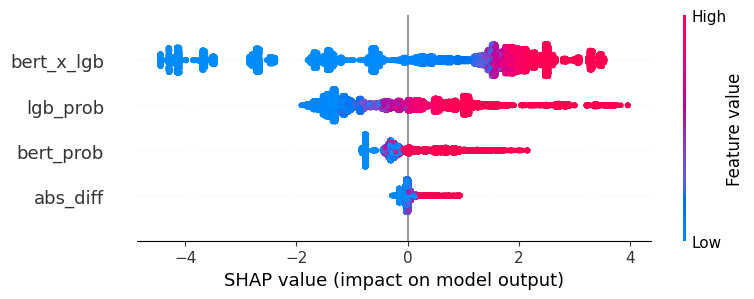

In [88]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap", "-q", "--break-system-packages"])
    import shap

explainer = shap.TreeExplainer(meta_model)
shap_values = explainer.shap_values(X_meta)

# для бинарной классификации LGBMClassifier может вернуть список [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_meta, feature_names=META_FEATURE_NAMES, show=True)